# Session 12 — Data Parallel and ZeRO

**Thirty-two virtual GPUs, a demo model that runs on top of them, and ZeRO
stages 1, 2 and 3 simulated to the byte.**

A virtual GPU here is a Python thread that owns a rank, its own slice of the
corpus and its own tensors, and that can reach another rank's tensors *only* by
calling a collective. That restriction is what makes the numbers below
measurements rather than assertions: every byte that crosses between ranks goes
through `all_reduce`, `reduce_scatter` or `all_gather` and is counted on the way
past, and every tensor an engine allocates is registered with a meter.

| # | the question | where it is answered |
|---|---|---|
| 1 | are these really 32 separate workers, and what do the collectives cost? | `experiments/e1_mesh.py` |
| 2 | do the four arrangements compute the same thing? | `experiments/e2_equivalence.py` |
| 3 | what does each stage cost in memory, wire and clock? | `experiments/e3_stages.py` |
| 4 | where is the memory wall, and which arrangements never clear it? | `experiments/e4_ladder.py` |
| 5 | how much of the traffic can be hidden behind the compute? | `experiments/e5_overlap.py` |

Every number below is computed when this notebook runs. Nothing is quoted.

## 0. Setup

In [1]:
import sys, pathlib, json
ROOT = pathlib.Path.cwd()                # walk up if opened from a subdirectory
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from IPython.display import Markdown, Image, display
import torch

from src.report import machine

def show(name):
    "Render an experiment's written-out findings inline."
    display(Markdown((ROOT / "results" / name).read_text()))

print(json.dumps(machine(), indent=2))

{
  "chip": "Apple M4",
  "platform": "macOS-26.6.2-arm64-arm-64bit-Mach-O",
  "python": "3.14.5",
  "torch": "2.13.0",
  "cores": 10,
  "device": "cpu (virtual GPUs are threads; nothing here uses an accelerator)"
}


---
# 1. Thirty-two virtual GPUs

`Mesh(32)` starts 32 threads, gives each one a rank and a barrier, and pins each
to a single torch thread so a rank cannot quietly borrow the machine's other
cores. Nothing is shared except through a collective.

In [2]:
import threading
from src.mesh import Mesh

def hello(rank, mesh):
    return (rank, threading.current_thread().name, torch.get_num_threads())

mesh = Mesh(32)
out = mesh.run(hello)
print(f"{len(out)} ranks, {len({o[1] for o in out})} distinct threads, "
      f"{out[0][2]} torch thread each")
print("first four:", out[:4])

32 ranks, 32 distinct threads, 1 torch thread each
first four: [(0, 'gpu00', 1), (1, 'gpu01', 1), (2, 'gpu02', 1), (3, 'gpu03', 1)]


### The collective identity the whole session rests on

A reduce-scatter followed by an all-gather **is** an all-reduce. Stages 1 and 2
do not send less than data parallelism does — they send the same two phases and
*keep* the slice that appears in between, which data parallelism computes and
throws away. Here it is on four ranks and eight numbers, small enough to read.

In [3]:
mesh = Mesh(4)
payload = [torch.tensor([float(r * 10 + i) for i in range(8)]) for r in range(4)]
for r, p in enumerate(payload):
    print(f"rank {r} starts with {p.tolist()}")

def both_ways(rank, mesh):
    direct = mesh.all_reduce(rank, payload[rank], "mean")
    shard  = mesh.reduce_scatter(rank, payload[rank], "mean")
    whole  = mesh.all_gather(rank, shard)
    return direct, shard, whole

res = mesh.run(both_ways)
print()
for r, (direct, shard, whole) in enumerate(res):
    print(f"rank {r}: keeps shard {shard.tolist()}  ->  gathers {whole.tolist()}")
print()
print("all_reduce           ", res[0][0].tolist())
print("gather(scatter(.))   ", res[0][2].tolist())
print("bitwise equal:", all(torch.equal(d, w) for d, _, w in res))

rank 0 starts with [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
rank 1 starts with [10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0]
rank 2 starts with [20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0]
rank 3 starts with [30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0]

rank 0: keeps shard [15.0, 16.0]  ->  gathers [15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0]
rank 1: keeps shard [17.0, 18.0]  ->  gathers [15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0]
rank 2: keeps shard [19.0, 20.0]  ->  gathers [15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0]
rank 3: keeps shard [21.0, 22.0]  ->  gathers [15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0]

all_reduce            [15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0]
gather(scatter(.))    [15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0]
bitwise equal: True


### And the ring, counted one send at a time

`ring_all_reduce` does the sends one at a time, each rank only ever handing a
chunk to `rank+1`: `W-1` sends to reduce and `W-1` to gather, each of `N/W`
bytes. That is where `2P` comes from — it is a count, not a convention.

world size 32: 62 sends per rank
counted:     507,904 bytes per rank
2N(W-1)/W:   507,904 bytes per rank
identical: True   = 1.9375N


# E1 · Thirty-two virtual GPUs, and three collectives

World size 32. Every rank is a thread with its own tensors, its own slice of the corpus and `torch.set_num_threads(1)`, so a rank cannot quietly borrow the machine's other cores either.

## They really are separate

| ranks | OS threads | distinct batches | tokens per rank | tokens per step |
| ----: | ---------: | ---------------: | --------------: | --------------: |
|    32 |         32 |               32 |             256 |           8,192 |

The first bytes each rank drew, to show the text differs and not just a hash:

| rank | thread | first 24 bytes of its first sequence |
| ---- | ------ | ------------------------------------ |
| 0    | gpu00  | ` at home against Wake Fo`           |
| 1    | gpu01  | `ified Chinese : 陈星�`                |
| 2    | gpu02  | `      'sigma_8': 0.8159,`           |
| 3    | gpu03  | `ndations from Bob Dowie `           |

A replacement character in that column is not a bug: the vocabulary is the 256 byte values, so a sequence boundary is free to land in the middle of a multi-byte codepoint. Nothing in this session depends on the tokenizer, and a byte vocabulary keeps the embedding table small enough that the sharding results below are about the transformer rather than about one large matrix.

## reduce-scatter + all-gather = all-reduce

32 ranks, 65,536 random fp32 numbers each. Each rank keeps a shard of 2,048 numbers in between.

| check                                           | result  |
| ----------------------------------------------- | ------- |
| bitwise equal on every rank                     | True    |
| max \|all_reduce − all_gather(reduce_scatter)\| | 0.0e+00 |
| every rank ended with the same answer           | True    |

This is the identity every later result leans on. Stage 1 and stage 2 do not send less than data parallelism does — they send the *same two phases* and keep the slice that appears in between them, which data parallelism computes and throws away.

## The ring, counted send by send

`ring_all_reduce` performs the sends one at a time, each rank only ever handing a chunk to `rank+1`. For 32 ranks that is 62 sends per rank (62 expected: 31 to reduce and 31 to gather), each one chunk of N/32.

|                                   | bytes per rank |
| --------------------------------- | -------------: |
| bytes counted, one send at a time |        507,904 |
| 2N(W−1)/W                         |        507,904 |
| in units of N                     |         1.9375 |
| identical                         |           True |

So `2P` is not a convention, it is a count. The ring's *answer* agrees with the direct reduction to 2.4e-07 absolute but is not bitwise identical to it (`bitwise_equal: False`), because a ring adds the ranks in ring order and a direct reduction adds them in rank order, and floating point addition is not associative. Real NCCL has exactly this property, which is why changing the world size of a real run changes its loss curve in the last decimal place.

## The cost, as the world grows

| world size | all-reduce | reduce-scatter | all-gather |
| ---------: | ---------: | -------------: | ---------: |
|          1 |    0.0000N |        0.0000N |    0.0000N |
|          2 |    1.0000N |        0.5000N |    0.5000N |
|          4 |    1.5000N |        0.7500N |    0.7500N |
|          8 |    1.7500N |        0.8750N |    0.8750N |
|         16 |    1.8750N |        0.9375N |    0.9375N |
|         32 |    1.9375N |        0.9688N |    0.9688N |

The cost per rank does not grow with the world — it *approaches* 2N and N from below and stops. Doubling the GPUs does not double anybody's traffic; it only stops the (W−1)/W discount from helping. That is the property that makes data parallelism scale at all.

## Pricing it for our model

30B parameters in bf16 is P = 60 GB.

| volume                                |  bytes | NVLink 450 GB/s | InfiniBand 50 GB/s | PCIe 60 GB/s |
| ------------------------------------- | -----: | --------------: | -----------------: | -----------: |
| 2P (data parallelism, ZeRO-1, ZeRO-2) | 120 GB |          0.27 s |             2.40 s |       2.00 s |
| 3P (ZeRO-3)                           | 180 GB |          0.40 s |             3.60 s |       3.00 s |

![](e1_mesh.png)


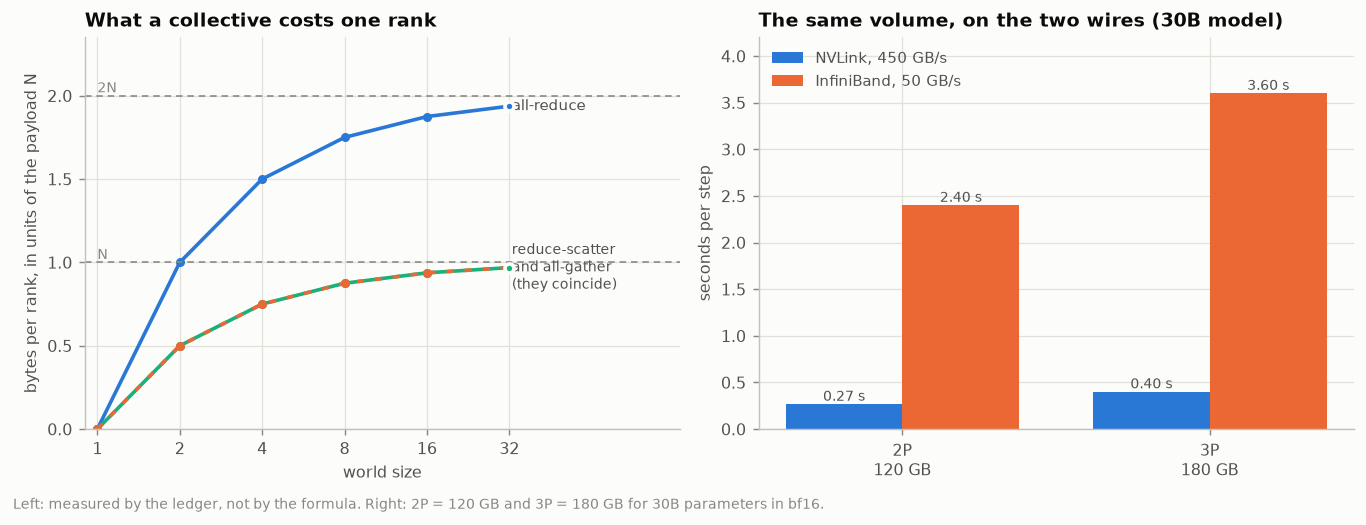

In [4]:
import experiments.e1_mesh as e1
mesh_stats = e1.main(verbose=False)
ring = mesh_stats["ring"]
print(f"world size {ring['world_size']}: {ring['sends_per_rank']} sends per rank")
print(f"counted:  {ring['measured_bytes_per_rank']:>10,.0f} bytes per rank")
print(f"2N(W-1)/W:{ring['formula_bytes_per_rank']:>10,.0f} bytes per rank")
print(f"identical: {ring['matches_formula']}   = {ring['in_units_of_N']:.4f}N")
show("e1_mesh.md")
display(Image(filename=str(ROOT / "results" / "e1_mesh.png")))

---
# 2. The demo model, and the sixteen bytes

An ordinary pre-norm decoder, but held in an unusual way: a group's parameters
are one flat tensor and `layer_forward` is a *function* that takes it. A model
whose weights live inside its modules cannot express "I do not have this layer
right now"; ZeRO-3 needs one that can.

The four engines differ in exactly one thing — which of the sixteen bytes per
weight a rank keeps and which it asks for when the moment comes.

In [5]:
from src.model import Config, total_params, group_numel
cfg = Config()
print(f"{cfg.n_layer} blocks · d_model {cfg.d_model} · {cfg.n_head} heads · "
      f"d_ff {cfg.d_ff} · context {cfg.max_seq} · vocab {cfg.vocab_size}")
print(f"{total_params(cfg):,} parameters in {cfg.n_groups} groups")
for g in range(cfg.n_groups):
    what = ("embeddings" if g == 0 else "norm + head" if g == cfg.n_groups - 1
            else f"block {g}")
    print(f"  group {g}: {group_numel(cfg, g):>9,}  {what}")

4 blocks · d_model 128 · 4 heads · d_ff 512 · context 128 · vocab 256
870,656 parameters in 6 groups
  group 0:    49,152  embeddings
  group 1:   197,120  block 1
  group 2:   197,120  block 2
  group 3:   197,120  block 3
  group 4:   197,120  block 4
  group 5:    33,024  norm + head


In [6]:
from src.engines import ENGINES, STAGE_ORDER
from src.mesh import Mesh

W = 8
rows = []
for name in STAGE_ORDER:
    def build(rank, mesh, name=name):
        e = ENGINES[name](rank, mesh, cfg)
        b = e.meter.breakdown()
        n = total_params(cfg)
        return (name, e.stage, b["weights"]/n, b["gradients"]/n,
                b["optimizer"]/n, e.bytes_per_weight())
    rows.append(Mesh(W).run(build)[0])

display(Markdown(
    "| arrangement | stage | bf16 weights | bf16 grads | fp32 master + moments | "
    "total bytes/weight |\n|---|---|---|---|---|---|\n" +
    "\n".join(f"| {a} | {b} | {c:.3f} | {d:.3f} | {e:.3f} | **{f:.3f}** |"
              for a, b, c, d, e, f in rows)))
print(f"world size {W}; the session notes give 16.00, 5.50, 3.75, 2.00")

| arrangement | stage | bf16 weights | bf16 grads | fp32 master + moments | total bytes/weight |
|---|---|---|---|---|---|
| data parallel | 0 | 2.000 | 2.000 | 12.000 | **16.000** |
| ZeRO-1 | 1 | 2.000 | 2.000 | 1.500 | **5.500** |
| ZeRO-2 | 2 | 2.000 | 0.250 | 1.500 | **3.750** |
| ZeRO-3 | 3 | 0.250 | 0.250 | 1.500 | **2.000** |

world size 8; the session notes give 16.00, 5.50, 3.75, 2.00


---
# 3. Four arrangements, one answer

Run them. Same data, same order, same optimizer. The memory per rank falls by
32x, the traffic rises for stage 3, and the weights do not change — not to eight
decimals, but in every bit.

In [7]:
from src.sim import train, max_weight_divergence

runs = {name: train(name, world_size=8, micro_batch=2, steps=6, cfg=cfg,
                    keep_weights=True)
        for name in STAGE_ORDER}
base = runs["data parallel"].weights

print(f"{'arrangement':<15}{'bytes/wt':>10}{'wire/step':>12}"
      f"{'final loss':>14}{'max |dw| vs DP':>17}")
for name, r in runs.items():
    d = max_weight_divergence(base, r.weights)
    print(f"{name:<15}{r.bytes_per_weight:>10.3f}{r.wire_in_P:>11.4f}P"
          f"{r.losses[-1]:>14.8f}{d:>17.1e}")
print()
print("bitwise identical to data parallelism:",
      all(all(torch.equal(base[g], r.weights[g]) for g in base)
          for r in runs.values()))

arrangement      bytes/wt   wire/step    final loss   max |dw| vs DP
data parallel      16.000     1.7500P    4.84704733          0.0e+00
ZeRO-1              5.500     1.7500P    4.84704733          0.0e+00
ZeRO-2              3.750     1.7500P    4.84704733          0.0e+00
ZeRO-3              2.000     2.6250P    4.84704733          0.0e+00

bitwise identical to data parallelism: True


32 ranks x 2 sequences vs 1 rank x 64 sequences, one step:
  loss differs by          1.8e-02
  gradient, averaged fp32  1.3e-06 relative, 0.0000 deg
  gradient, bf16 per rank  3.3e-04 relative, 0.0198 deg

averaging deleted: the 32 copies drift 6.23e-03 apart and nothing raises an error


# E2 · Data parallelism is one big batch, and ZeRO does not change the answer

## 1 · Thirty-two ranks on two sequences each *is* one rank on sixty-four

The claim is about the gradient, so check the gradient, before any optimizer has had a chance to amplify anything. One step, 64 sequences: once as 32 ranks averaging their 2-sequence gradients, once as a single machine on all 64 at once.

|                                               | 32 ranks x 2 sequences | 1 rank x 64 sequences |                difference |
| --------------------------------------------- | ---------------------: | --------------------: | ------------------------: |
| the loss                                      |           5.6259175837 |          5.6259179115 |                   3.3e-07 |
| the gradient, averaged in fp32                |                      — |                     — | 1.3e-06 relative, 0.0000° |
| the gradient, each rank rounded to bf16 first |                      — |                     — | 3.3e-04 relative, 0.0198° |

The first line is the claim and it holds: averaging 32 partial gradients reproduces the 64-sequence gradient to 1e-06 relative and 0.0000 degrees, which is fp32 summation noise and nothing else. The two runs are the same run.

The third line is the part worth keeping. A rank does not put its fp32 gradient on the wire — it puts 2 bytes per weight on the wire, which is where the second row of the sixteen comes from. Rounding each rank's *partial* gradient to bf16 and then averaging is not the same as rounding the whole gradient once: it costs 3.3e-04 relative and 0.020 degrees of direction, 251x the fp32 figure. That is a real cost of distributing the work, it is invisible in any loss curve, and the optimizer does not leave it small:

| after N steps | max \|w(32 ranks) − w(1 rank)\| |
| ------------: | ------------------------------: |
|             1 |                         7.3e-04 |
|             2 |                         7.3e-04 |
|             4 |                         7.3e-04 |
|             8 |                         7.3e-04 |
|            12 |                         6.1e-04 |

The first row is the surprise, and it is Adam's doing rather than bf16's. On step 1 the update is `-lr * m_hat / (sqrt(v_hat) + eps)` with `m_hat = g` and `v_hat = g^2`, so it is `-lr * sign(g)` whatever the size of `g`. A gradient element that differs by 1e-7 between the two runs moves the weight by a full `2 * lr` if that difference crosses zero — and `2 * lr = 6e-4`, which is the column. The scale-free step is the amplifier; bf16 only supplies the disagreement. It does not compound after that, because the same normalisation that amplifies the difference also bounds it.

After 12 steps the weights differ by 6.1e-04 and the losses by 1.8e-02 nats, and neither run is the wrong one. They are two equally valid roundings of the same mathematical step. That is the honest answer to whether the distributed run is the same run: yes in exact arithmetic, and to within one bf16 rounding per rank in this one.

## 2 · The four arrangements, compared weight by weight

World size 32, 12 steps, identical data.

| arrangement   | bytes/weight | wire/step | final loss | max \|Δw\| vs DP | bitwise |
| ------------- | -----------: | --------: | ---------: | ---------------: | ------- |
| data parallel |       16.000 |   1.9375P | 4.54751873 |          0.0e+00 | yes     |
| ZeRO-1        |        4.375 |   1.9375P | 4.54751873 |          0.0e+00 | yes     |
| ZeRO-2        |        2.438 |   1.9375P | 4.54751873 |          0.0e+00 | yes     |
| ZeRO-3        |        0.500 |   2.9062P | 4.54751873 |          0.0e+00 | yes     |

Three columns move and one does not. The memory per rank falls by 32x, the traffic rises for stage 3, and the weights do not change at all — not to eight decimals, but in every bit of every one of 870,656 numbers. **That is the claim ZeRO makes, and it is the only claim it makes.** It is a statement about addresses, not about arithmetic.

## 3 · The control: the same code with the averaging deleted

`NoAverage` is `DataParallel` with the `all_reduce` line removed. Each rank updates its own copy from its own gradients — which are correct gradients, for the two sequences that rank happened to draw.

|                              | data parallelism | averaging deleted |
| ---------------------------- | ---------------: | ----------------: |
| weights on the wire per step |          1.9375P |           0.0000P |
| spread between the 32 copies |          0.0e+00 |          6.23e-03 |
| final loss on rank 0         |         4.547519 |          4.616174 |

After 12 steps the 32 copies are 6.23e-03 apart and moving apart. Nothing raises an error; the loss still falls; each rank is still training a perfectly good language model. It is just that there are now 32 of them, each one trained on 1/32 of the data, and the run has quietly stopped being the run it was supposed to be. The all-reduce is not a synchronisation detail — it is the thing that makes the 32 copies one model.

![](e2_equivalence.png)


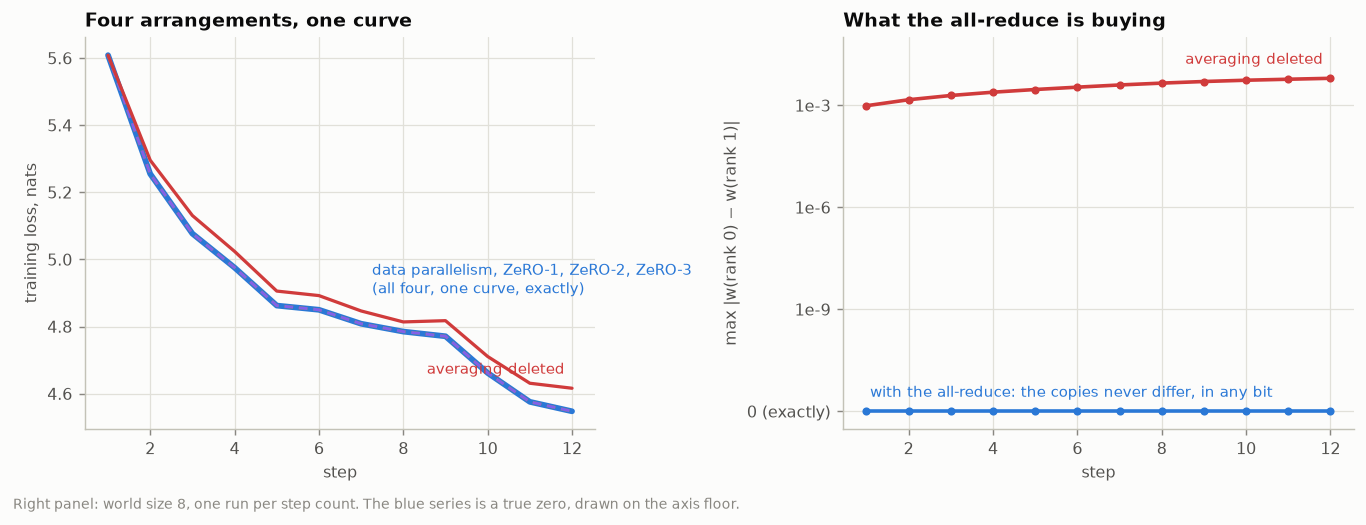

In [8]:
import experiments.e2_equivalence as e2
eq = e2.main(verbose=False)            # ~1 minute: it trains about 30 models
g = eq["big_batch"]["gradients"]
print("32 ranks x 2 sequences vs 1 rank x 64 sequences, one step:")
print(f"  loss differs by          {eq['big_batch']['loss_abs_diff']:.1e}")
print(f"  gradient, averaged fp32  {g['fp32']['relative_l2']:.1e} relative, "
      f"{g['fp32']['angle_degrees']:.4f} deg")
print(f"  gradient, bf16 per rank  {g['bf16']['relative_l2']:.1e} relative, "
      f"{g['bf16']['angle_degrees']:.4f} deg")
print(f"\naveraging deleted: the 32 copies drift "
      f"{eq['control']['rank_spread']:.2e} apart and nothing raises an error")
show("e2_equivalence.md")
display(Image(filename=str(ROOT / "results" / "e2_equivalence.png")))

---
# 4. What each stage costs

The meter is told about every tensor as it is allocated, so the bytes-per-weight
column is an audit of what the engine did. The formula column is the session
notes' arithmetic. They are computed from opposite ends and never see each other.

memory audit matches the formula in every cell: True
wire count matches the formula in every cell:   True

data parallel    16.000 B/wt   1.9375P     447.0 GiB at 30B    does not fit
ZeRO-1            4.375 B/wt   1.9375P     122.2 GiB at 30B    does not fit
ZeRO-2            2.438 B/wt   1.9375P      68.1 GiB at 30B            fits
ZeRO-3            0.500 B/wt   2.9062P      14.0 GiB at 30B            fits


# E3 · What each stage costs

870,656 parameters (4 blocks, d_model 128, 6 groups), 32 virtual GPUs, 2 sequences each, 8,192 tokens per step, 8 steps.

## The memory, audited

Measured by a meter that is told about every tensor as it is allocated, then compared against the formula the session notes give. The two columns are computed from opposite ends and never see each other.

| arrangement   | bytes/weight measured | formula, W=32 | resident per rank | peak per rank | saving |
| ------------- | --------------------: | ------------: | ----------------: | ------------: | -----: |
| data parallel |               16.0000 |       16.0000 |         13.29 MiB |     14.66 MiB |   1.0x |
| ZeRO-1        |                4.3750 |        4.3750 |          3.63 MiB |      5.01 MiB |   3.7x |
| ZeRO-2        |                2.4375 |        2.4375 |          2.02 MiB |      3.78 MiB |   6.6x |
| ZeRO-3        |                0.5000 |        0.5000 |          0.42 MiB |      2.17 MiB |  32.0x |

Identical in every row: `memory_matches_formula: True`. At world size 8 the same audit reproduces the session's own table — 16.00, 5.50, 3.75, 2.00 — exactly (`True`).

### Where the peak actually goes

Resident state is not what fills a card. This is the largest the meter ever saw, broken out by what was holding it.

| arrangement   | weights | gradients | optimizer | grad bucket | gathered | activations | peak MiB |
| ------------- | ------: | --------: | --------: | ----------: | -------: | ----------: | -------: |
| data parallel |    1.66 |      1.66 |      9.96 |        0.75 |     0.00 |        0.62 |    14.66 |
| ZeRO-1        |    1.66 |      1.66 |      0.31 |        0.75 |     0.00 |        0.62 |     5.01 |
| ZeRO-2        |    1.66 |      0.05 |      0.31 |        1.13 |     0.00 |        0.62 |     3.78 |
| ZeRO-3        |    0.05 |      0.05 |      0.31 |        1.13 |     0.00 |        0.62 |     2.17 |

Three things are visible there that the bytes-per-weight column hides.

**The gradient buffer is 2 bytes a weight and stages 0 and 1 never get it back.** It is allocated once and zeroed between steps, exactly as PyTorch's `.grad` is, so it is resident state and not a transient. That is why ZeRO-1 bottoms out at 4 bytes a weight however many GPUs are added: 2 for the weights plus 2 for the gradients, neither of which it shards.

**Stages 2 and 3 pay a bucket instead.** They reduce-scatter each group's gradient as the backward pass produces it and drop the full-size buffer immediately, so what they hold is one group's worth at a time rather than the whole model's. The `grad bucket` column is that transient, and it is the thing DeepSpeed's `bucket_size` names — bigger buckets, fewer and more efficient transfers, more memory held at once.

**Activations do not shard at all.** Every arrangement holds the same 0.88 MiB of them, because they belong to the rank's own sequences and no other rank has a copy to share. ZeRO says nothing about activation memory; that is what activation checkpointing is for, and this model uses it — only the tensor entering each group is kept, and the rest is recomputed in the backward pass.

## The wire, counted

| arrangement   | per rank per step, measured | formula | collective calls | actual bytes |
| ------------- | --------------------------: | ------: | ---------------: | -----------: |
| data parallel |                     1.9375P | 1.9375P |                6 |      3.37 MB |
| ZeRO-1        |                     1.9375P | 1.9375P |               12 |      3.37 MB |
| ZeRO-2        |                     1.9375P | 1.9375P |               12 |      3.37 MB |
| ZeRO-3        |                     2.9062P | 2.9062P |               18 |      5.06 MB |

`wire_matches_formula: True`. Stages 1 and 2 send precisely what data parallelism sends. Stage 3 sends half as much again, and the extra half is one all-gather of the weights in the forward pass and one more in the backward — 18 calls a step against 6, because every group is now fetched twice and returned twice.

## The clock

These are threads on one laptop CPU, so the seconds below are not a prediction about a GPU cluster — 32 ranks share 10 cores, and the `in collectives` column is barrier and memcpy time, not network time. What the table *is* good for is the shape: what each arrangement does with a step, and how much of one it spends not computing.

| arrangement   | ms/step | forward+backward | AdamW | casts and copies | in collectives | share stopped |
| ------------- | ------: | ---------------: | ----: | ---------------: | -------------: | ------------: |
| data parallel |   564.5 |            278.3 |  42.7 |             10.4 |          233.1 |           41% |
| ZeRO-1        |   478.9 |            260.0 |  31.3 |             10.9 |          176.7 |           37% |
| ZeRO-2        |   480.1 |            253.6 |  30.6 |             12.2 |          183.7 |           38% |
| ZeRO-3        |   485.9 |            249.7 |  33.5 |              9.2 |          193.6 |           40% |

The four middle columns are disjoint and add to the first: time inside a collective is taken out of the phase it happened in, so stage 2's reduce-scatters are counted once, in the last column, and not again in the backward pass they interrupt.

The AdamW column is the interesting failure. The sharded stages update a thirty-second of the weights and it buys them almost nothing: 42.7 ms a step against 33.5. Timed on its own, away from the mesh, the same arithmetic behaves the way it should:

| parameters | one rank's shard (W=32) | AdamW on all, ms | AdamW on the shard, ms | speedup |
| ---------: | ----------------------: | ---------------: | ---------------------: | ------: |
|    870,656 |                  27,208 |            0.723 |                  0.031 |   23.7x |
|  8,000,000 |                 250,000 |            8.349 |                  0.201 |   41.5x |
| 64,000,000 |               2,000,000 |           65.605 |                  1.704 |   38.5x |

24x at this model's size and 38x at 64M — past 32x, because a 2M-element shard also fits in cache and a 64M-element vector does not. So the saving is real and it is large. What the 8-step run above cannot show is *this machine*: 32 Python threads on 10 cores, where a tensor operation on 27,000 numbers spends its time in dispatch — holding the interpreter lock — rather than in arithmetic. The ranks queue behind each other no matter how small their shards get.

That is the honest boundary of this simulator and it is worth stating plainly: **the bytes it reports are exact and the seconds it reports are about a laptop.** Memory per rank and traffic per step are counted, not modelled, and they would be the same numbers on 32 H100s. Wall-clock is not, which is why experiment 5 prices the time from the byte counts and a stated bandwidth instead of from this machine's clock.

Thirty-one of every thirty-two of data parallelism's updates are a computation the other ranks are performing at the same moment on the same inputs. *That* is the redundancy the **O** in Zero Redundancy Optimizer names, and it is the one saving in this session that costs nothing at all: the sharded stages do less arithmetic, not merely less storing.

## The same per-weight figures, at 30 billion

Nothing here is re-derived. The measured bytes-per-weight from the first table, multiplied by 30e9, against a card that holds 74.5 GiB.

| arrangement   | bytes/weight | state per GPU | on an 80 GB card | wire per step | NVLink | InfiniBand |
| ------------- | -----------: | ------------: | ---------------- | ------------: | -----: | ---------: |
| data parallel |      16.0000 |     447.0 GiB | does not fit     |        116 GB | 0.26 s |     2.33 s |
| ZeRO-1        |       4.3750 |     122.2 GiB | does not fit     |        116 GB | 0.26 s |     2.33 s |
| ZeRO-2        |       2.4375 |      68.1 GiB | fits             |        116 GB | 0.26 s |     2.33 s |
| ZeRO-3        |       0.5000 |      14.0 GiB | fits             |        174 GB | 0.39 s |     3.49 s |

At 32 GPUs, on the training state alone: data parallelism needs 447 GiB a card and ZeRO-1 needs 122 GiB, and a card has 74.5. ZeRO-2 fits with 6.4 GiB to spare, which has to cover activations, and ZeRO-3 fits with room to spare on far fewer GPUs. Experiment 4 walks the world size to find where each line crosses.

![](e3_stages.png)


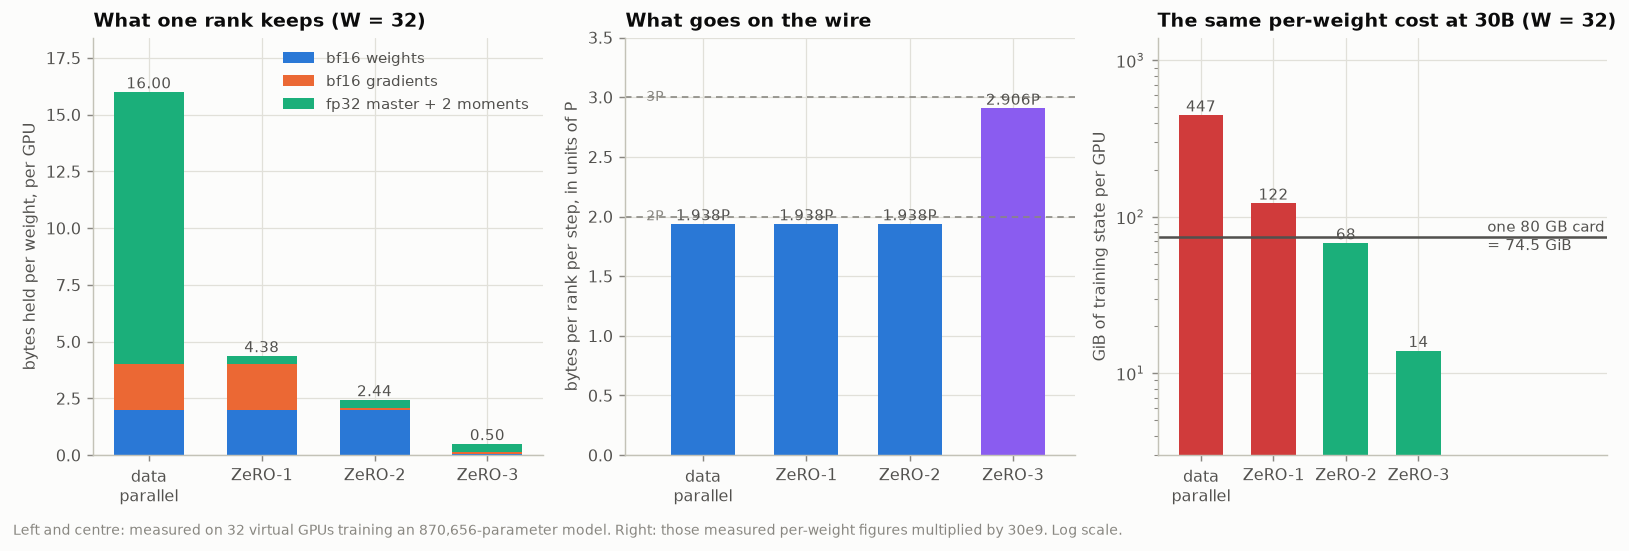

In [9]:
import experiments.e3_stages as e3
stages = e3.main(verbose=False)
print(f"memory audit matches the formula in every cell: "
      f"{stages['memory_matches_formula']}")
print(f"wire count matches the formula in every cell:   "
      f"{stages['wire_matches_formula']}")
print()
for r in stages["rows"]:
    v = stages["v5_projection"][r["engine"]]
    print(f"{r['engine']:<15}{r['bytes_per_weight_measured']:>8.3f} B/wt"
          f"{r['wire_in_P_measured']:>9.4f}P"
          f"{v['state_gib']:>10,.1f} GiB at 30B  "
          f"{'fits' if v['fits_80gb_card'] else 'does not fit':>14}")
show("e3_stages.md")
display(Image(filename=str(ROOT / "results" / "e3_stages.png")))

---
# 5. The memory wall

Walk the world size and watch what each arrangement does with the extra GPUs.
Two of them get cheaper per rank without limit. Two of them stop — and where
they stop has a model size attached to it.

measured bytes per weight matches the formula in all 28 cells: True

weights + gradients stay replicated under DP and ZeRO-1: 4 bytes/weight
4 bytes fills a 74.5 GiB card at 20.0B parameters
our model is 30B, needing 111.8 GiB -- at any world size

  data parallel   fits an 80 GB card never
  ZeRO-1          fits an 80 GB card never
  ZeRO-2          fits an 80 GB card from 32 GPUs
  ZeRO-3          fits an 80 GB card from 8 GPUs


# E4 · The memory wall, one virtual GPU to sixty-four

Every cell below comes from an engine that ran. The world size on the left is a real number of threads, each holding real tensors, and the meter counted them.

## Bytes per weight, measured

| arrangement   |    W=1 |    W=2 |    W=4 |    W=8 |   W=16 |   W=32 |   W=64 |
| ------------- | -----: | -----: | -----: | -----: | -----: | -----: | -----: |
| data parallel | 16.000 | 16.000 | 16.000 | 16.000 | 16.000 | 16.000 | 16.000 |
| ZeRO-1        | 16.000 | 10.000 |  7.000 |  5.500 |  4.750 |  4.375 |  4.188 |
| ZeRO-2        | 16.000 |  9.000 |  5.500 |  3.750 |  2.875 |  2.438 |  2.219 |
| ZeRO-3        | 16.000 |  8.000 |  4.000 |  2.000 |  1.000 |  0.500 |  0.250 |

Against the formula, in all 28 cells: `measured_matches_formula: True`.

Read the rows rather than the columns and the session's argument appears on its own:

- **Data parallelism is flat.** 16.000 at every world size. Buying GPUs buys throughput and nothing else; each one still holds the entire model, the entire gradient and the entire optimizer state.
- **ZeRO-1 approaches 4 and stops.** It shards the twelve bytes of optimizer state and leaves the 2-byte weights and 2-byte gradients replicated. 4.375 at W=32, 4.188 at W=64, 4.000 in the limit.
- **ZeRO-2 approaches 2 and stops**, for the same reason with one fewer term: the weights are still replicated.
- **ZeRO-3 has no floor.** 16/W, all the way down. It is the only arrangement where adding a GPU reduces what every GPU holds.

## The same rows at 30 billion parameters

Measured bytes per weight × 30e9, against a card that holds 74.5 GiB. Cells in bold fit.

| arrangement   | 1 GPU | 2 GPUs | 4 GPUs |   8 GPUs |  16 GPUs |  32 GPUs |  64 GPUs |
| ------------- | ----: | -----: | -----: | -------: | -------: | -------: | -------: |
| data parallel | 447.0 |  447.0 |  447.0 |    447.0 |    447.0 |    447.0 |    447.0 |
| ZeRO-1        | 447.0 |  279.4 |  195.6 |    153.7 |    132.7 |    122.2 |    117.0 |
| ZeRO-2        | 447.0 |  251.5 |  153.7 |    104.8 |     80.3 | **68.1** | **62.0** |
| ZeRO-3        | 447.0 |  223.5 |  111.8 | **55.9** | **27.9** | **14.0** |  **7.0** |

| arrangement   | fits an 80 GB card from | largest model at W=32 |
| ------------- | ----------------------: | --------------------: |
| data parallel |                   never |                  5.0B |
| ZeRO-1        |                   never |                 18.3B |
| ZeRO-2        |                 32 GPUs |                 32.8B |
| ZeRO-3        |                  8 GPUs |                160.0B |

## Why two of the rows never fit

Not because 30 billion is a large number — because of what stays replicated. Data parallelism and ZeRO-1 both keep the 2-byte weights and the 2-byte gradients on every card. That is 4 bytes a weight that no world size touches, and 4 bytes a weight has a model size attached to it:

|                                                   |           |
| ------------------------------------------------- | --------: |
| a card                                            |  74.5 GiB |
| replicated bytes per weight (weights + gradients) |         4 |
| parameters that fill the card                     |     20.0B |
| our model                                         |       30B |
| what it needs, at 4 bytes a weight                | 111.8 GiB |

**20.0 billion parameters is the boundary**, and it is a property of the arrangement rather than of the hardware budget. A 20B model sits on the line; ours sits 1.5x past it. Every thousand-GPU cluster in the world is still short of a card for it under ZeRO-1.

## What the table is not counting

Training state only. The activations are extra, they belong to the rank's own sequences, and no ZeRO stage shards them — this run measured 0.44 MiB of them per rank for 1 sequence of 128 tokens, *with* checkpointing already on. A real V5 micro-batch is far larger and the activation term with it, so the ZeRO-2 row's 68.1 GiB at 32 GPUs is not a configuration that fits — it is a configuration with 6.4 GiB left for everything else, which is not enough. Read the fitted cells as an upper bound on what is possible, not as a plan.

![](e4_ladder.png)


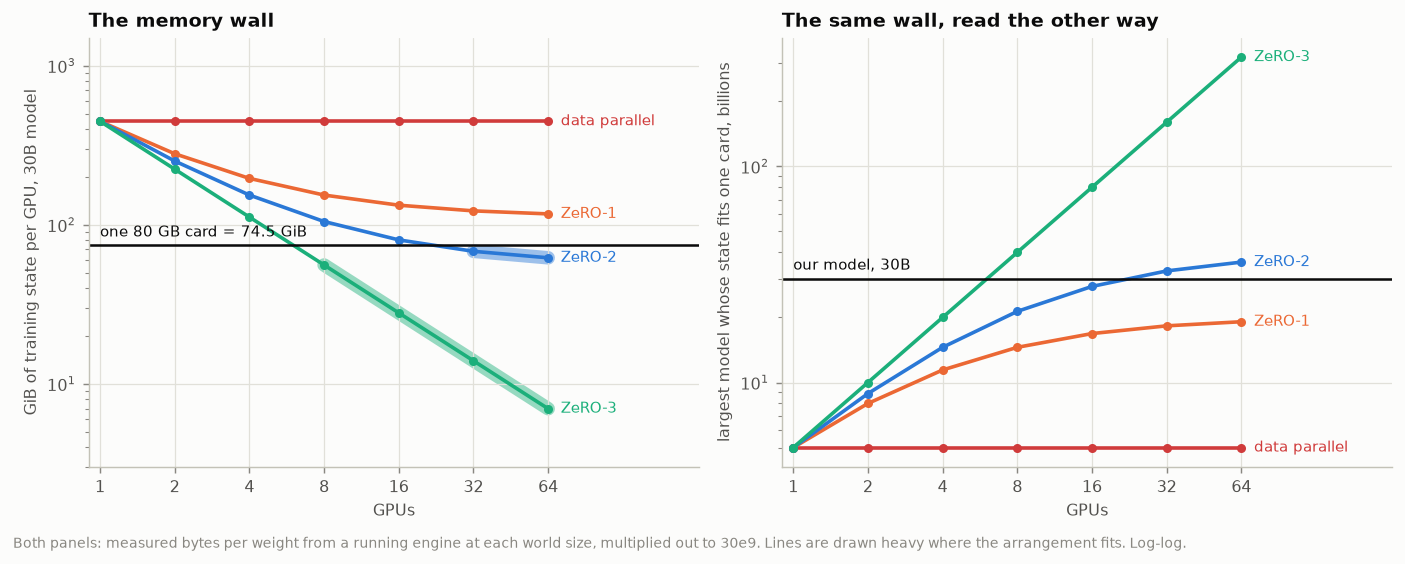

In [10]:
import experiments.e4_ladder as e4
ladder = e4.main(verbose=False)
b = ladder["boundary"]
print(f"measured bytes per weight matches the formula in all "
      f"{len(ladder['measured'])} cells: {ladder['measured_matches_formula']}")
print()
print(f"weights + gradients stay replicated under DP and ZeRO-1: 4 bytes/weight")
print(f"4 bytes fills a {b['card_gib']:.1f} GiB card at "
      f"{b['params_that_fill_a_card']/1e9:.1f}B parameters")
print(f"our model is {b['v5_params']/1e9:.0f}B, needing {b['v5_needs_gib']:.1f} GiB "
      f"-- at any world size")
print()
for row in ladder["ladder"]:
    fits = f"from {row['fits_from']} GPUs" if row["fits_from"] else "never"
    print(f"  {row['engine']:<15} fits an 80 GB card {fits}")
show("e4_ladder.md")
display(Image(filename=str(ROOT / "results" / "e4_ladder.png")))

---
# 6. Overlapping the communication with the compute

The thread mesh cannot answer the timing question — its wire is a memcpy between
two Python lists — so the timing question is answered with a discrete-event
model instead: measured per-layer shape, counted volume, stated bandwidth.

2P over InfiniBand, no overlap:
  64 x H100: 2.33 s of wire against 7.10 s of compute = 33%
  64 x B200: 2.33 s of wire against 3.12 s of compute = 75%  <- same bytes, faster card

with overlap, step time above its own compute:
  data parallel | 64 x H100 | InfiniBand     +1.2%   96% hidden
  ZeRO-1 | 64 x H100 | InfiniBand            +1.1%   97% hidden
  ZeRO-2 | 64 x H100 | InfiniBand            +1.1%   97% hidden
  ZeRO-3 | 64 x H100 | InfiniBand            +1.4%   97% hidden
  data parallel | 64 x B200 | InfiniBand     +8.6%   89% hidden
  ZeRO-1 | 64 x B200 | InfiniBand            +5.7%   92% hidden
  ZeRO-2 | 64 x B200 | InfiniBand            +5.7%   92% hidden
  ZeRO-3 | 64 x B200 | InfiniBand           +12.2%   89% hidden


# E5 · Communication that happens during computation costs nothing

## The profile the simulation runs on

A 12-block model, one thread, nothing else running, timestamped at every group boundary in both directions.

| group                 | parameters | forward ms | backward ms | share of the backward |
| --------------------- | ---------: | ---------: | ----------: | --------------------: |
| group 0  (embeddings) |     49,152 |       0.04 |        0.13 |                  0.7% |
| group 1  (block)      |    197,120 |       0.51 |        1.40 |                  8.1% |
| group 2  (block)      |    197,120 |       0.51 |        1.40 |                  8.1% |
| group 12  (block)     |    197,120 |       0.51 |        1.44 |                  8.3% |
| group 13  (head)      |     33,024 |       0.04 |        0.32 |                  1.9% |

The whole backward is 2.82x the whole forward here, against the 2x that 6N FLOPs a token predicts, because this repository's backward recomputes each group's activations before differentiating them and so carries the forward's work a second time. The projection below uses the 2x, not the 2.82x, because the cluster step times it starts from are for a production step and recomputation is a choice that step may not have made. Assuming the smaller backward is the conservative direction: a longer backward is a longer window to hide transfers in.

The blocks cost the same as each other and the two ends do not. That shape is what is carried over to a 48-block, 30-billion-parameter model; nothing else about this machine is. The *time* comes from the step times a real cluster reports, the *volume* from experiment 3's byte counts, and a step is taken to be one third forward and two thirds backward, because a step is 6N FLOPs a token and the backward is 4 of them.

## Without overlap

Everything sent after the pass that produced it, at 30B and world size 32.

| arrangement   | card      | wire       | volume | wire time | ÷ compute | step, serial |
| ------------- | --------- | ---------- | -----: | --------: | --------: | -----------: |
| data parallel | 64 x H100 | NVLink     |  1.94P |    0.26 s |        4% |       7.36 s |
| ZeRO-3        | 64 x H100 | NVLink     |  2.91P |    0.39 s |        5% |       7.49 s |
| data parallel | 64 x H100 | InfiniBand |  1.94P |    2.33 s |       33% |       9.43 s |
| ZeRO-3        | 64 x H100 | InfiniBand |  2.91P |    3.49 s |       49% |      10.59 s |
| data parallel | 64 x B200 | NVLink     |  1.94P |    0.26 s |        8% |       3.38 s |
| ZeRO-3        | 64 x B200 | NVLink     |  2.91P |    0.39 s |       12% |       3.51 s |
| data parallel | 64 x B200 | InfiniBand |  1.94P |    2.33 s |       75% |       5.45 s |
| ZeRO-3        | 64 x B200 | InfiniBand |  2.91P |    3.49 s |      112% |       6.61 s |

The 2P-over-InfiniBand rows are the session's own figures — 33% on H100 and 75% on B200. The volume did not change between those two rows. The compute it has to hide behind got shorter, and that is the entire reason faster cards make this harder.

## The bucket sweep

Data parallelism's 2P, sent during a backward pass that is 0.67 of the step. 48 blocks, so a bucket of 1 is 50 transfers and a bucket of 48 is two.

| bucket, layers | transfers | backward pass | exposed tail | hidden |
| -------------: | --------: | ------------: | -----------: | -----: |
|              1 |        50 |       4.818 s |      0.085 s |    96% |
|              2 |        25 |       4.827 s |      0.094 s |    96% |
|              3 |        17 |       4.861 s |      0.127 s |    95% |
|              4 |        13 |       4.907 s |      0.174 s |    93% |
|              6 |         9 |       5.001 s |      0.268 s |    88% |
|              8 |         7 |       5.095 s |      0.361 s |    84% |
|             12 |         5 |       5.282 s |      0.549 s |    76% |
|             16 |         4 |       5.469 s |      0.736 s |    68% |
|             24 |         3 |       5.844 s |      1.110 s |    52% |
|             48 |         2 |       6.952 s |      2.218 s |     5% |

*(64 × H100 over InfiniBand: a 4.73 s backward window carrying 2.33 s of traffic.)*

The cost of a large bucket is not the transfer, it is *when* the transfer can start. A 48-layer bucket cannot leave until the backward pass has reached layer 0, so all of it is exposed; a 1-layer bucket leaves as each layer finishes and only the last one — the embedding, which is small — is left over at the end.

## Where the smallest bucket stops being the best one

At a 10 µs launch cost the smallest bucket always wins, which is not what production settings look like. The optimum is set by the ratio of the fixed cost of a transfer to the time the bytes themselves take, so the honest thing is to sweep the fixed cost and find the crossover rather than to assert a bucket size. B200, InfiniBand, 2P:

| fixed cost per transfer | best bucket, layers | backward pass | at bucket = 1 |
| ----------------------: | ------------------: | ------------: | ------------: |
|                 0.01 ms |                   1 |       2.347 s |       2.347 s |
|                  0.1 ms |                   1 |       2.352 s |       2.352 s |
|                    1 ms |                   1 |       2.396 s |       2.396 s |
|                    5 ms |                   2 |       2.506 s |       2.592 s |
|                   10 ms |                   3 |       2.591 s |       2.837 s |
|                   25 ms |                   6 |       2.775 s |       3.585 s |
|                   50 ms |                   8 |       2.986 s |       4.835 s |

The crossover is at about 5.0 ms of fixed cost per transfer. Below it, start transfers as early as possible; above it, the launch cost of 50 transfers outweighs the earlier start and the bucket should grow. A production `bucket_size` of a few hundred megabytes is a bet about which side of that line the cluster is on — and the V4 configuration in the session notes bet 2e8 bytes.

## The whole step, all four arrangements

Both windows, each with the best bucket and prefetch depth found by search. `overhead` is how much longer the step is than its own compute.

| arrangement   | card      | wire       | on the wire | exposed | hidden |   step | overhead |
| ------------- | --------- | ---------- | ----------: | ------: | -----: | -----: | -------: |
| data parallel | 64 x H100 | NVLink     |      0.26 s |  0.01 s |    98% | 7.11 s |    +0.1% |
| ZeRO-1        | 64 x H100 | NVLink     |      0.26 s |  0.01 s |    98% | 7.11 s |    +0.1% |
| ZeRO-2        | 64 x H100 | NVLink     |      0.26 s |  0.01 s |    98% | 7.11 s |    +0.1% |
| ZeRO-3        | 64 x H100 | NVLink     |      0.39 s |  0.01 s |    98% | 7.11 s |    +0.1% |
| data parallel | 64 x H100 | InfiniBand |      2.33 s |  0.08 s |    96% | 7.18 s |    +1.2% |
| ZeRO-1        | 64 x H100 | InfiniBand |      2.33 s |  0.08 s |    97% | 7.18 s |    +1.1% |
| ZeRO-2        | 64 x H100 | InfiniBand |      2.33 s |  0.08 s |    97% | 7.18 s |    +1.1% |
| ZeRO-3        | 64 x H100 | InfiniBand |      3.49 s |  0.10 s |    97% | 7.20 s |    +1.4% |
| data parallel | 64 x B200 | NVLink     |      0.26 s |  0.01 s |    97% | 3.13 s |    +0.2% |
| ZeRO-1        | 64 x B200 | NVLink     |      0.26 s |  0.01 s |    98% | 3.13 s |    +0.2% |
| ZeRO-2        | 64 x B200 | NVLink     |      0.26 s |  0.01 s |    98% | 3.13 s |    +0.2% |
| ZeRO-3        | 64 x B200 | NVLink     |      0.39 s |  0.01 s |    98% | 3.13 s |    +0.2% |
| data parallel | 64 x B200 | InfiniBand |      2.33 s |  0.27 s |    89% | 3.39 s |    +8.6% |
| ZeRO-1        | 64 x B200 | InfiniBand |      2.33 s |  0.18 s |    92% | 3.30 s |    +5.7% |
| ZeRO-2        | 64 x B200 | InfiniBand |      2.33 s |  0.18 s |    92% | 3.30 s |    +5.7% |
| ZeRO-3        | 64 x B200 | InfiniBand |      3.49 s |  0.38 s |    89% | 3.50 s |   +12.2% |

Three readings.

**Inside a node, everything hides.** Every NVLink row is within a per cent of its own compute time, stage 3 included. A run whose traffic stays inside one node barely has a communication cost at all, which is the answer to the session's second open question: put as much of the traffic inside a node as will fit.

**Between nodes, the split matters more than the total.** Data parallelism and ZeRO-1 move the same 2P on 64 x B200, and data parallelism pays 8.6% for it against ZeRO-1's 5.7%. The reason is not volume, it is *windows*: data parallelism has to push all 2P through the backward pass, while ZeRO-1 and ZeRO-2 put one P in the backward and the other in the next forward, where there is compute going spare. Sharding the optimizer state bought a better communication schedule as well as the memory.

**Stage 3 is the one that runs out of window.** It has 3P to move and, on 64 x B200 over InfiniBand, a step of 3.12 s to hide 3.49 s of traffic in — and 0.15 s of its backward pass is spent standing still waiting for weights that have not arrived. That is the practical form of the 2P-versus-3P difference, and it is the argument for keeping a stage 3 group inside one node.

![](e5_overlap.png)


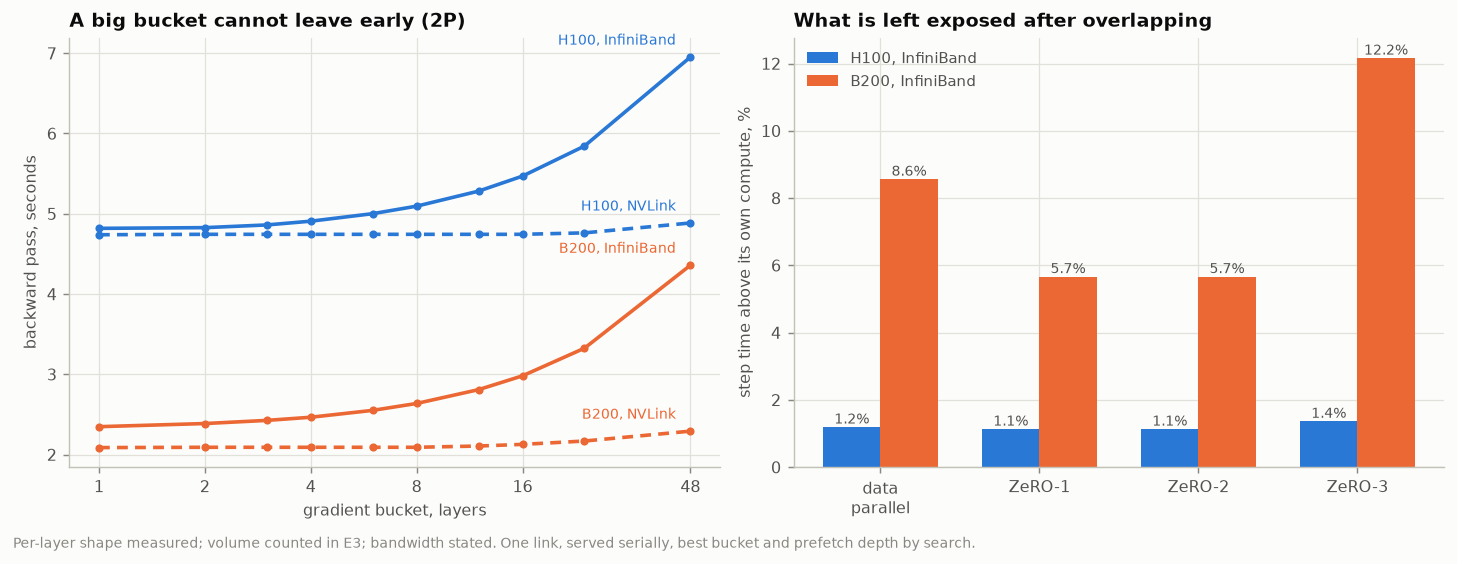

In [11]:
import experiments.e5_overlap as e5
ov = e5.main(verbose=False)
base_h = ov["baseline"]["data parallel | 64 x H100 | InfiniBand"]
base_b = ov["baseline"]["data parallel | 64 x B200 | InfiniBand"]
print(f"2P over InfiniBand, no overlap:")
print(f"  64 x H100: {base_h['wire_seconds']:.2f} s of wire against "
      f"{base_h['compute_seconds']:.2f} s of compute = "
      f"{100*base_h['ratio']:.0f}%")
print(f"  64 x B200: {base_b['wire_seconds']:.2f} s of wire against "
      f"{base_b['compute_seconds']:.2f} s of compute = "
      f"{100*base_b['ratio']:.0f}%  <- same bytes, faster card")
print()
print("with overlap, step time above its own compute:")
for k, v in ov["steps"].items():
    if "InfiniBand" in k:
        print(f"  {k:<40}{v['overhead_pct']:>+7.1f}%   "
              f"{100*v['hidden_fraction']:.0f}% hidden")
show("e5_overlap.md")
display(Image(filename=str(ROOT / "results" / "e5_overlap.png")))

---
# What the 32 GPUs said

One table, one line each, every number from the cells above.

In [12]:
dp, z1, z2, z3 = stages["rows"]
v5 = stages["v5_projection"]
b = ladder["boundary"]
ib_b = ov["steps"]["data parallel | 64 x B200 | InfiniBand"]
z3_b = ov["steps"]["ZeRO-3 | 64 x B200 | InfiniBand"]

rows = [
    ("1", "32 virtual GPUs, 32 threads, 32 different batches",
     f"{mesh_stats['separateness']['global_batch_tokens']:,} tokens a step, "
     f"{mesh_stats['separateness']['tokens_per_rank']} per rank"),
    ("1", "a ring all-reduce, counted send by send",
     f"{ring['in_units_of_N']:.4f}N per rank = 2N(W-1)/W, exactly"),
    ("2", "averaging 32 partial gradients vs one big batch",
     f"{eq['big_batch']['gradients']['fp32']['relative_l2']:.0e} relative -- "
     "the same run"),
    ("2", "bf16 on the wire, per rank, before averaging",
     f"{eq['big_batch']['gradients']['bf16']['relative_l2']:.0e} relative; "
     "Adam turns it into 2*lr on step 1"),
    ("2", "ZeRO-1, ZeRO-2 and ZeRO-3 against data parallelism",
     "bitwise identical, every weight, every step"),
    ("2", "the same code with the all-reduce deleted",
     f"the 32 copies drift {eq['control']['rank_spread']:.0e} apart, silently"),
    ("3", "bytes per weight, measured at W=32",
     f"{dp['bytes_per_weight_measured']:.3f} / "
     f"{z1['bytes_per_weight_measured']:.3f} / "
     f"{z2['bytes_per_weight_measured']:.3f} / "
     f"{z3['bytes_per_weight_measured']:.3f} -- the formula, in every cell"),
    ("3", "bytes on the wire per step",
     f"{dp['wire_in_P_measured']:.3f}P for stages 0-2, "
     f"{z3['wire_in_P_measured']:.3f}P for stage 3"),
    ("3", "AdamW on a shard vs on everything",
     f"{stages['adam_scaling'][-1]['speedup']:.0f}x at "
     f"{stages['adam_scaling'][-1]['n']//10**6}M parameters"),
    ("4", "the floor DP and ZeRO-1 cannot get under",
     f"4 bytes a weight, which fills a card at "
     f"{b['params_that_fill_a_card']/1e9:.0f}B parameters"),
    ("4", "30B on an 80 GB card",
     f"ZeRO-2 from 32 GPUs ({v5['ZeRO-2']['state_gib']:.1f} GiB), "
     f"ZeRO-3 from 8 ({v5['ZeRO-3']['state_gib']:.1f} GiB)"),
    ("5", "2P over InfiniBand, as a share of compute",
     f"{100*base_h['ratio']:.0f}% on H100, {100*base_b['ratio']:.0f}% on B200 -- "
     "same bytes"),
    ("5", "what overlap leaves exposed, B200 over InfiniBand",
     f"{ib_b['overhead_pct']:+.1f}% for data parallelism, "
     f"{z3_b['overhead_pct']:+.1f}% for ZeRO-3"),
]
display(Markdown(
    "| # | what was measured | what it said |\n|---|---|---|\n"
    + "\n".join(f"| {a} | {b_} | {c} |" for a, b_, c in rows)))

| # | what was measured | what it said |
|---|---|---|
| 1 | 32 virtual GPUs, 32 threads, 32 different batches | 8,192 tokens a step, 256 per rank |
| 1 | a ring all-reduce, counted send by send | 1.9375N per rank = 2N(W-1)/W, exactly |
| 2 | averaging 32 partial gradients vs one big batch | 1e-06 relative -- the same run |
| 2 | bf16 on the wire, per rank, before averaging | 3e-04 relative; Adam turns it into 2*lr on step 1 |
| 2 | ZeRO-1, ZeRO-2 and ZeRO-3 against data parallelism | bitwise identical, every weight, every step |
| 2 | the same code with the all-reduce deleted | the 32 copies drift 6e-03 apart, silently |
| 3 | bytes per weight, measured at W=32 | 16.000 / 4.375 / 2.438 / 0.500 -- the formula, in every cell |
| 3 | bytes on the wire per step | 1.938P for stages 0-2, 2.906P for stage 3 |
| 3 | AdamW on a shard vs on everything | 38x at 64M parameters |
| 4 | the floor DP and ZeRO-1 cannot get under | 4 bytes a weight, which fills a card at 20B parameters |
| 4 | 30B on an 80 GB card | ZeRO-2 from 32 GPUs (68.1 GiB), ZeRO-3 from 8 (14.0 GiB) |
| 5 | 2P over InfiniBand, as a share of compute | 33% on H100, 75% on B200 -- same bytes |
| 5 | what overlap leaves exposed, B200 over InfiniBand | +8.6% for data parallelism, +12.2% for ZeRO-3 |

ZeRO is a statement about addresses, not about arithmetic. Every stage in this
notebook computed the identical weights, bit for bit, out of a rank that held
between 16 and 0.5 bytes for each of them. What changed was who was holding
which byte at which moment, and how much of the fetching could be arranged to
happen while the machine was busy anyway.

The thing worth carrying out of this session is that both of the numbers that
decide a distributed run — what one rank holds, and what one rank sends — are
countable in advance, on a laptop, before a cluster is booked.